# Prequisites

In [12]:
pip install pyreadr

In [13]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from itertools import combinations
from scipy.special import factorial
from scipy.optimize import minimize
from scipy.stats import sem, t
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datetime import datetime, timedelta
import pyreadr
import statsmodels.api as sm
from scipy import stats

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

#Definitions

In [14]:
k = 2
n = 50
X = np.random.normal(loc=0, scale=1, size=(n, k))
y = 2 * X[:, 0] + 2 * X[:, 1] + np.random.normal(loc=0, scale=0.1, size=n)
reg = LinearRegression(fit_intercept = False).fit(X, y)
beta_hat = reg.coef_.reshape(-1, 1)

In [15]:
def simulate(n, k):
  X = np.random.normal(loc=0, scale=1, size=(n, k))
  y = 1.5 * X.sum(axis=1) + np.random.normal(loc=0, scale=0.1, size=n)
  reg = LinearRegression(fit_intercept = False).fit(X, y)
  beta_hat = reg.coef_.reshape(-1, 1)
  return X, y, reg, beta_hat

In [16]:
def d(xi, xj):
  return float(np.linalg.norm(xi-xj))

def f(xi, A = None):
  if A is None:
    A = np.eye(len(xi))
  return reg.predict((A @ xi).reshape(1,-1))

def D(xi, xj, f=f, A = None):
  if A is None:
    A = np.eye(len(xi))
  return abs(f(xi,A)-f(xj,A))

def fairness_error(xi, xj, f=f, A = None, c=1):
  if A is None:
    A = np.eye(len(xi))
  return max(0, D(xi, xj, f, A) - d(xi,xj)/(c*np.sqrt(len(xi))))

def sfe(xi, xj, f=f, A = None, c=1):
  if A is None:
    A = np.eye(len(xi))
  return fairness_error(xi, xj, f, A, c)**2

def SSFE(X, f=f, A = None, c=1):
  if A is None:
    A = np.eye(len(X[0]))
  ssfe = 0
  for xi in X:
    for xj in X:
      ssfe += sfe(xi, xj, f, A, c)
  if isinstance(ssfe, int):
    return ssfe/2
  else:
    return float(ssfe[0])/2

def SSR(y, X, f=f, A = None):
  if A is None:
    A = np.eye(len(X[0]))
  ssr = 0
  for i, xi in enumerate(X):
    ssr += (y[i] - f(xi, A))**2
  return float(ssr[0])

def SSRE(X, A = None):
  if A is None:
    A = np.eye(len(X[0]))
  deviation_sum = 0.0
  for i in range(len(X)):
    xi = X[i].reshape(-1, 1)
    deviation = A @ xi - xi
    deviation_sum += float(deviation.T @ deviation)
  return deviation_sum

def viol_percentage(y, X, A = None, c=1):
  if A is None:
    A = np.eye(len(X[0]))
  total_pairs = (len(X)*(len(X)-1))/2
  count_pairs = 0

  for i, j in combinations(range(len(X)), 2):
    diff = (X[i] - X[j]).reshape(-1, 1)
    term1 = abs(float(diff.T @ A.T @ beta_hat))
    term2 = np.linalg.norm(diff) / (c*np.sqrt(k))
    if term1 > term2:
      count_pairs += 1

  return (100*count_pairs)/total_pairs

In [17]:
def fairness_objective(A_flat, X, beta_hat, c=1):
    k = X.shape[1]
    A = A_flat.reshape(k, k)
    total = 0.0

    for i, j in combinations(range(len(X)), 2):
        diff = (X[i] - X[j]).reshape(-1, 1)

        term1 = abs(float(diff.T @ A.T @ beta_hat))
        term2 = np.linalg.norm(diff) / (c*np.sqrt(k))
        delta = term1 - term2

        total += max(0.0, delta)**2

    return total

In [18]:
def regression_constraint(A_flat, X, y, beta_hat, lmbda, beta_0 = 0):
    k = X.shape[1]
    A = A_flat.reshape(k, k)

    residual_sum = 0.0

    for i in range(len(X)):
        xi = X[i].reshape(-1, 1)
        prediction = float(beta_0 + xi.T @ A.T @ beta_hat)
        residual_sum += (y[i] - prediction) ** 2

    return lmbda - residual_sum

In [19]:
def representation_constraint(A_flat, X, mu):
    k = X.shape[1]
    A = A_flat.reshape(k, k)

    AX_minus_X = X @ A.T - X
    deviation_sum = np.sum(AX_minus_X**2)

    return mu - deviation_sum

In [20]:
def optimize_A(X, y, beta_hat, lam, n_restarts=25, method='SLSQP', beta_0 = 0, c = 1):
    k = X.shape[1]

    constraint = {'type': 'ineq','fun': lambda A_flat:regression_constraint(A_flat, X, y, beta_hat, lam, beta_0)}

    best_result = None
    best_objective = np.inf

    while best_result is None:

        A0 = np.random.normal(size=(k, k)).ravel()
        result = minimize(
            fun=fairness_objective,
            x0=A0,
            args=(X, beta_hat, c),
            method=method,
            constraints=[constraint],
            options={'maxiter': 300,'ftol': 1e-7,'disp': False}
        )

        if result.success:
            obj_val = result.fun
            if obj_val < best_objective:
                best_objective = obj_val
                best_result = result
    return {'A': best_result.x.reshape(k, k),
          'objective': best_result.fun,
          'success': best_result.success,
          'message': best_result.message}

In [21]:
def optimize_A_rep(X, y, beta_hat, lam, n_restarts=25, method='SLSQP', beta_0 = 0, c = 1):
    k = X.shape[1]

    constraint = {'type': 'ineq','fun': lambda A_flat:representation_constraint(A_flat, X, lam)}

    best_result = None
    best_objective = np.inf

    while best_result is None:

        A0 = np.random.normal(size=(k, k)).ravel()
        result = minimize(
            fun=fairness_objective,
            x0=A0,
            args=(X, beta_hat, c),
            method=method,
            constraints=[constraint],
            options={'maxiter': 300,'ftol':1e-7,'disp':False}
        )

        if result.success:
            obj_val = result.fun
            if obj_val < best_objective:
                best_objective = obj_val
                best_result = result

    return {'A': best_result.x.reshape(k, k),
          'objective': best_result.fun,
          'success': best_result.success,
          'message': best_result.message}

In [22]:
def optimize_A_both(X, y, beta_hat, lam, mu,n_restarts=25,method='SLSQP',beta_0=0,c=1):

    k = X.shape[1]

    regression_cons = {'type': 'ineq','fun': lambda A_flat: regression_constraint( A_flat, X, y, beta_hat, lam, beta_0)}
    representation_cons = {'type': 'ineq','fun': lambda A_flat: representation_constraint(A_flat, X, mu)}
    constraints = [regression_cons, representation_cons]

    best_result = None
    best_objective = np.inf
    while best_result is None:
        A0 = np.random.normal(size=(k, k)).ravel()
        result = minimize(
            fun=fairness_objective,
            x0=A0,
            args=(X, beta_hat, c),
            method=method,
            constraints=constraints,
            options={
                'maxiter': 300,
                'ftol': 1e-7,
                'disp': False }
        )

        if result.success:
            if result.fun < best_objective:
                best_objective = result.fun
                best_result = result

    return {'A': best_result.x.reshape(k, k),
          'objective': best_result.fun,
          'success': best_result.success,
          'message': best_result.message}

# Results: Simulation

## Problem 1

values for k:   0%|          | 0/3 [00:00<?, ?it/s]

feature index 0 started at 2026-06-20 01:30:28.613296


20 simulations:   0%|          | 0/20 [00:00<?, ?it/s]

SSR iterations:   0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

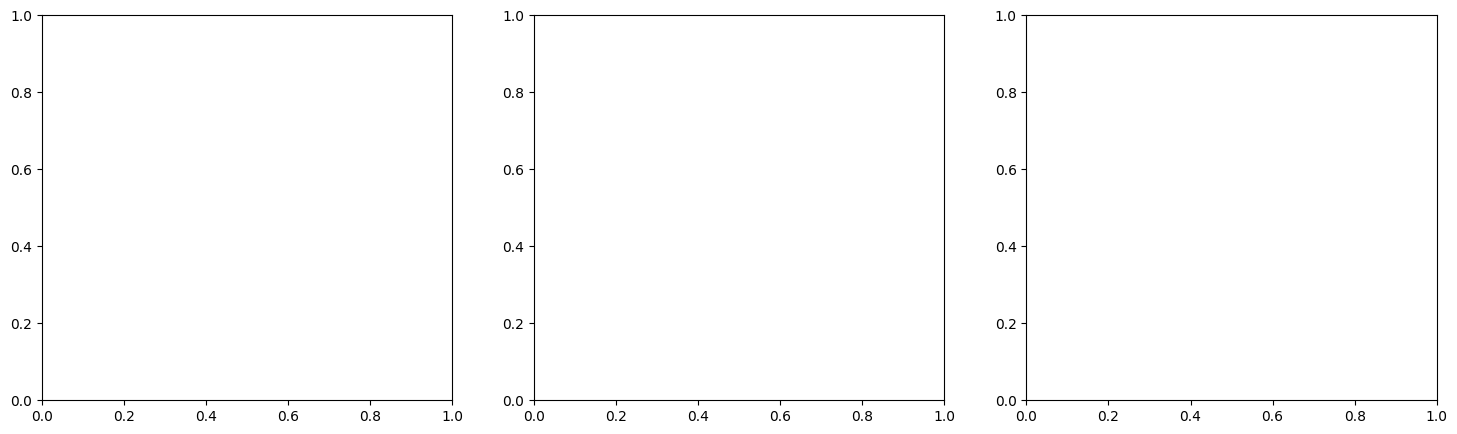

In [ ]:
n_params = [50, 100, 200]
k_params = [2, 3, 4]
s = 20
n = 50

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
highest_ssfe = 0
lowest_ssfe = 0

for plot_idx, k in enumerate(tqdm(k_params, desc="values for k")):
  print(f"feature index {plot_idx} started at {str(datetime.now() + timedelta(hours=2))}")
  x_steps = 10
  Y = np.zeros((s, x_steps))
  V = np.zeros((s, x_steps))
  SSR_values = []

  for simu in tqdm(range(s), desc=f"{s} simulations", leave=False):
    #print(f"simulation: {simu+1}")
    X, y, reg, beta_hat = simulate(n, k)
    SSR = np.sum((y - X @ beta_hat.flatten())**2)
    SSR_range = np.logspace(np.log10(SSR), np.log10(100*SSR), x_steps)
    SSR_values.append(SSR)
    SSFE_range = []
    viol_range = []

    for SSR_A in tqdm(SSR_range, desc="SSR iterations", leave=False):
      idx += 1
      solutions = optimize_A(
        X=X,
        y=y,
        beta_hat=beta_hat,
        lam=SSR_A,
        n_restarts=1
      )
      SSFE_A = SSFE(X, f=f, A=solutions['A'])
      SSFE_range.append(SSFE_A)

      viol_range.append(viol_percentage(y, X, A=solutions['A']))
    Y[simu, :] = SSFE_range
    V[simu, :] = viol_range

  # Confidence interval for SSFE
  confidence = 0.95
  df = s - 1
  t_critical = t.ppf((1 + confidence) / 2, df)

  mean_y = np.mean(Y, axis=0)
  stderr = sem(Y, axis=0)
  margin_ssfe = t_critical * stderr
  lower_ssfe = mean_y - margin_ssfe
  lower_ssfe = [max(0, x) for x in lower_ssfe]
  upper_ssfe = mean_y + margin_ssfe
  highest_ssfe = max(highest_ssfe, max(upper_ssfe))
  lowest_ssfe = min(lowest_ssfe, min(lower_ssfe))

  # Confidence interval for violations
  mean_v = np.mean(V, axis=0)
  stderr = sem(V, axis=0)
  margin_viol = t_critical * stderr
  lower_v = mean_v - margin_viol
  upper_v = mean_v + margin_viol

  # Plot
  ax1 = axes[plot_idx]
  mean_SSR = round(np.mean(SSR_values), 2)
  var_SSR = np.var(SSR_values)

  ax1.plot(np.logspace(0, 2, x_steps), mean_y, label='SSFE')
  ax1.fill_between(np.logspace(0, 2, x_steps), lower_ssfe, upper_ssfe, alpha=0.3)
  ax1.set_xscale('log')
  ax1.set_xlabel(rf'$\lambda \; (SSR \sim ({mean_SSR}, {var_SSR:.2e}))$', fontsize=18)
  if plot_idx == 0:
    ax1.set_ylabel(r'$SSFE_A$', fontsize=18)

  ax2 = ax1.twinx()
  ax2.plot(np.logspace(0, 2, x_steps), mean_v, linestyle='--', label='Violation %', color="red")
  ax2.fill_between(np.logspace(0, 2, x_steps), lower_v, upper_v, alpha=0.3, color = "red")
  if plot_idx == 2:
    ax2.set_ylabel('Violation Percentage', fontsize=18)
  ax2.set_ylim(0, 100)

  ax1.grid(linestyle='--', color='gray', alpha=0.2)

  tick_positions = [1, 10, 100]
  tick_labels = [r'$SSR$', r'$10SSR$', r'$100SSR$']
  ax1.set_xticks(tick_positions)
  ax1.set_xticklabels(tick_labels)

for ax in axes:
    ax.set_ylim(lowest_ssfe, highest_ssfe)
print(f"done at {str(datetime.now() + timedelta(hours=2))}")
plt.tight_layout()
plt.show()


## Problem 2

values for n:   0%|          | 0/3 [00:00<?, ?it/s]

feature index 0 started at 2026-06-20 01:31:09.378519


20 simulations:   0%|          | 0/20 [00:00<?, ?it/s]

SSRE iterations:   0%|          | 0/10 [00:00<?, ?it/s]

SSRE iterations:   0%|          | 0/10 [00:00<?, ?it/s]

...

SSRE iterations:   0%|          | 0/10 [00:00<?, ?it/s]

SSRE iterations:   0%|          | 0/10 [00:00<?, ?it/s]

SSRE iterations:   0%|          | 0/10 [00:00<?, ?it/s]

SSRE iterations:   0%|          | 0/10 [00:00<?, ?it/s]

done at 2026-06-20 03:27:45.002522


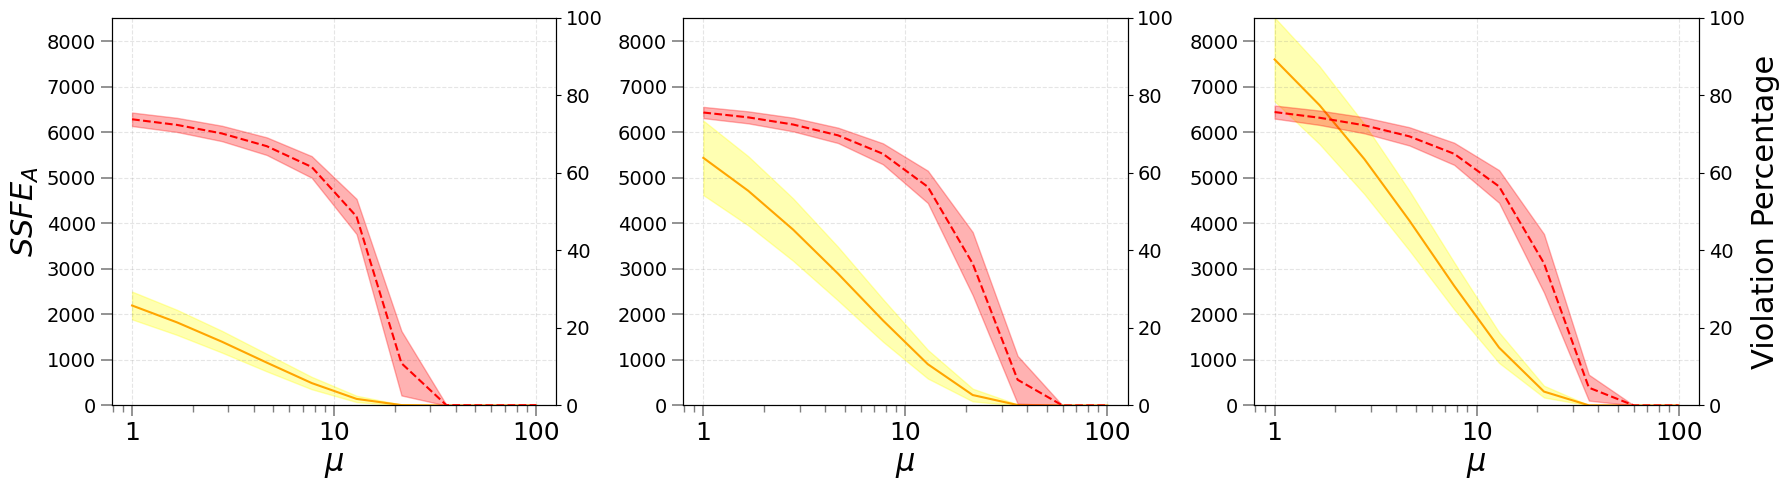

In [ ]:
n_params = [50, 75, 100]
k_params = [2, 3, 4]
s = 20
n = 50
x_steps = 10

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
highest_ssfe = 1
lowest_ssfe = 0

for plot_idx, k in enumerate(tqdm(k_params, desc="values for n")):
  print(f"feature index {plot_idx} started at {str(datetime.now() + timedelta(hours=2))}")

  Y = np.zeros((s, x_steps))
  V = np.zeros((s, x_steps))
  SSRE_range = np.logspace(np.log10(1), np.log10(100), num=x_steps)

  for simu in tqdm(range(s), desc=f"{s} simulations", leave=False):
    X, y, reg, beta_hat = simulate(n, k)

    SSFE_range = []
    viol_range = []

    for SSRE_A in tqdm(SSRE_range, desc="SSRE iterations", leave=False):
      solutions = optimize_A_rep(
        X=X,
        y=y,
        beta_hat=beta_hat,
        lam=SSRE_A,
        n_restarts=1
      )
      SSFE_A = SSFE(X, f=f, A=solutions['A'])
      SSFE_range.append(SSFE_A)

      viol_range.append(viol_percentage(y, X, A=solutions['A']))
    Y[simu, :] = SSFE_range
    V[simu, :] = viol_range

  # Confidence interval for SSFE
  confidence = 0.95
  df = s - 1
  t_critical = t.ppf((1 + confidence) / 2, df)

  mean_y = np.mean(Y, axis=0)
  stderr = sem(Y, axis=0)
  margin_ssfe = t_critical * stderr
  lower_ssfe = mean_y - margin_ssfe
  lower_ssfe = [max(0, x) for x in lower_ssfe]
  upper_ssfe = mean_y + margin_ssfe
  highest_ssfe = max(highest_ssfe, max(upper_ssfe))
  lowest_ssfe = min(lowest_ssfe, min(lower_ssfe))

  # Confidence interval for violations
  mean_v = np.mean(V, axis=0)
  stderr = sem(V, axis=0)
  margin_viol = t_critical * stderr
  lower_v = mean_v - margin_viol
  upper_v = mean_v + margin_viol

  # Plot
  ax1 = axes[plot_idx]

  ax1.plot(SSRE_range, mean_y, label='SSFE', color="orange")
  ax1.fill_between(SSRE_range, lower_ssfe, upper_ssfe, alpha=0.3, color="yellow")
  ax1.set_xscale('log')
  ax1.set_xlabel(rf'$\mu$', fontsize=22)
  ax1.tick_params(axis='y', labelsize=14)
  ax1.tick_params(axis='both', which='major', length=8, width=1.2, color='gray')
  ax1.tick_params(axis='both', which='minor', length=5, width=1, color='gray')
  if plot_idx == 0:
    ax1.set_ylabel(r'$SSFE_A$', fontsize=22)

  ax2 = ax1.twinx()
  ax2.plot(SSRE_range, mean_v, linestyle='--', label='Violation %', color="red")
  ax2.tick_params(axis='y', labelsize=14)
  ax2.fill_between(SSRE_range, lower_v, upper_v, alpha=0.3, color = "red")
  if plot_idx == 2:
    ax2.set_ylabel('Violation Percentage', fontsize=22)
  ax2.set_ylim(0, 100)

  ax1.grid(linestyle='--', color='gray', alpha=0.2)

  tick_positions = [1, 10, 100]
  tick_labels = [1, 10, 100]
  ax1.set_xticks(tick_positions)
  ax1.set_xticklabels(tick_labels, fontsize=18)

for ax in axes:
    ax.set_ylim(lowest_ssfe, highest_ssfe)
print(f"done at {str(datetime.now() + timedelta(hours=2))}")
plt.tight_layout()
plt.show()


# Results: Empirical

## Data preparation

In [23]:
data = pyreadr.read_r('nlsy97.rdata')
df = data['nlsy97']
df = df[(df["wage"] > 0) & (df["yeduc"] > 0) & (df["exp"] > 0) & (df["age2017"] > 0)]
df["logwage"] = np.log(df["wage"])
df["exp2"] = df["exp"]**2
print(df[["wage","logwage","yeduc","exp","exp2","age2017"]].var())
df = df[["logwage","yeduc","exp","exp2","age2017"]].reset_index(drop=True)


wage       1.713276e+07
logwage    4.664963e-01
yeduc      1.190266e+01
exp        1.387153e+01
exp2       1.208303e+04
age2017    1.958176e+00
dtype: float64


/tmp/ipykernel_17985/3565856876.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["logwage"] = np.log(df["wage"])
/tmp/ipykernel_17985/3565856876.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["exp2"] = df["exp"]**2


In [24]:
y = df["logwage"].to_numpy()
X1 = df[["yeduc","exp"]].to_numpy()
reg = LinearRegression(fit_intercept = True).fit(X1, y)
beta_0 = reg.intercept_
beta_hat = reg.coef_.reshape(-1, 1)

## Problem 1

models:   0%|          | 0/3 [00:00<?, ?it/s]

feature index 0 started at 2026-06-22 12:43:43.888449


20 simulations:   0%|          | 0/20 [00:00<?, ?it/s]

SSR iterations:   0%|          | 0/8 [00:00<?, ?it/s]

SSR iterations:   0%|          | 0/8 [00:00<?, ?it/s]

...

SSR iterations:   0%|          | 0/8 [00:00<?, ?it/s]

SSR iterations:   0%|          | 0/8 [00:00<?, ?it/s]

SSR iterations:   0%|          | 0/8 [00:00<?, ?it/s]

SSR iterations:   0%|          | 0/8 [00:00<?, ?it/s]

done at 2026-06-22 20:00:36.173688


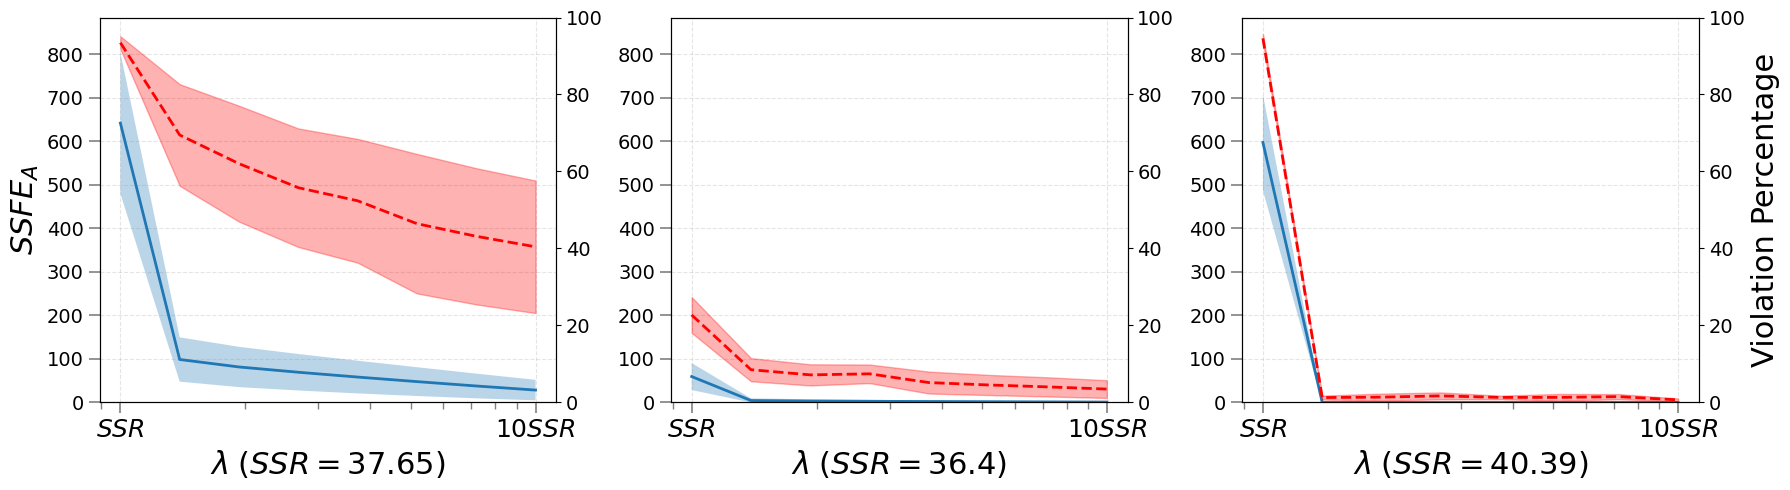

In [ ]:
y = df["logwage"].to_numpy()

feature_sets = [
    ("yeduc + exp", ["yeduc", "exp"]),
    ("yeduc + exp + exp2", ["yeduc", "exp", "exp2"]),
    ("yeduc + exp + age2017", ["yeduc", "exp", "age2017"])
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
highest_ssfe = 1
lowest_ssfe = 0
c = 100
s = 20
n = 100
x_steps = 8
confidence = 0.95

for plot_idx, (model_name, columns) in enumerate(tqdm(feature_sets, desc="models")):
  print(f"feature index {plot_idx} started at {str(datetime.now() + timedelta(hours=2))}")

  k = len(columns)
  Y = np.zeros((s, x_steps))
  V = np.zeros((s, x_steps))
  SSR_values = []

  for simu in tqdm(range(s), desc=f"{s} simulations", leave=False):
    df_sample = df.sample(n=n, replace=True)
    y_sample = df_sample["logwage"].to_numpy()
    X_sample = df_sample[columns].to_numpy()

    reg = LinearRegression(fit_intercept = True).fit(X_sample, y_sample)
    beta_0 = reg.intercept_
    beta_hat = reg.coef_.reshape(-1, 1)

    SSR = np.sum((y_sample - beta_0 - X_sample @ beta_hat.flatten())**2)
    SSR_values.append(SSR)

    SSR_range = np.logspace(np.log10(SSR), np.log10(10*SSR), x_steps)

    SSFE_range = np.zeros(x_steps)
    viol_range = np.zeros(x_steps)

    for idx, SSR_A in enumerate(tqdm(SSR_range, desc="SSR iterations", leave=False)):
      solutions = optimize_A(
        X=X_sample,
        y=y_sample,
        beta_hat=beta_hat,
        lam=SSR_A,
        n_restarts=1,
        beta_0 = beta_0,
        c = c
      )

      SSFE_A = SSFE(X=X_sample, f=f, A=solutions['A'], c=c)
      SSFE_range[idx] = SSFE_A
      viol_range[idx] = viol_percentage(y_sample, X_sample, A=solutions['A'], c=c)
    Y[simu, :] = SSFE_range
    V[simu, :] = viol_range

  # Confidence interval for SSFE
  df_ci = s - 1
  t_critical = t.ppf((1 + confidence) / 2, df_ci)

  mean_y = np.mean(Y, axis=0)
  stderr = sem(Y, axis=0)
  margin_ssfe = t_critical * stderr
  lower_ssfe = np.maximum(mean_y - margin_ssfe, 0)
  upper_ssfe = mean_y + margin_ssfe
  highest_ssfe = max(highest_ssfe, max(upper_ssfe))
  lowest_ssfe = min(lowest_ssfe, min(lower_ssfe))

  # Confidence interval for violations
  mean_v = np.mean(V, axis=0)
  stderr = sem(V, axis=0)
  margin_viol = t_critical * stderr
  lower_v = mean_v - margin_viol
  upper_v = mean_v + margin_viol

  # Plot
  ax1 = axes[plot_idx]
  mean_SSR = round(np.mean(SSR_values), 2)
  var_SSR = np.var(SSR_values)

  ax1.plot(np.logspace(0, 1, x_steps), mean_y, label='SSFE', linewidth=2)
  ax1.fill_between(np.logspace(0, 1, x_steps), lower_ssfe, upper_ssfe, alpha=0.3)
  ax1.set_xscale('log')
  ax1.set_xlabel(rf'$\lambda \; (SSR \sim ({mean_SSR}, {var_SSR:.2e}))$', fontsize=22)
  ax1.tick_params(axis='y', labelsize=14)
  ax1.tick_params(axis='both', which='major', length=8, width=1.2, color='gray')
  ax1.tick_params(axis='both', which='minor', length=5, width=1, color='gray')
  if plot_idx == 0:
    ax1.set_ylabel(r'$SSFE_A$', fontsize=22)

  ax2 = ax1.twinx()
  ax2.plot(np.logspace(0, 1, x_steps), mean_v, linestyle='--', label='Violation %', color="red", linewidth=2)
  ax2.tick_params(axis='y', labelsize=14)
  ax2.fill_between(np.logspace(0, 1, x_steps), lower_v, upper_v, alpha=0.3, color = "red")
  if plot_idx == 2:
    ax2.set_ylabel('Violation Percentage', fontsize=22)
  ax2.set_ylim(0, 100)

  ax1.grid(linestyle='--', color='gray', alpha=0.2)

  tick_positions = [1, 10]
  tick_labels = [
      r'$SSR$',
      r'$10SSR$'
  ]
  ax1.set_xticks(tick_positions)
  ax1.set_xticklabels(tick_labels, fontsize=18)
for ax in axes:
    ax.set_ylim(lowest_ssfe, 1.1*highest_ssfe)

print(f"done at {str(datetime.now() + timedelta(hours=2))}")
plt.tight_layout()
plt.show()



## Problem 2

models:   0%|          | 0/3 [00:00<?, ?it/s]

feature index 0 started at 2026-06-23 12:38:04.449619


20 simulations:   0%|          | 0/20 [00:00<?, ?it/s]

SSRE iterations:   0%|          | 0/8 [00:00<?, ?it/s]

SSRE iterations:   0%|          | 0/8 [00:00<?, ?it/s]

...

SSRE iterations:   0%|          | 0/8 [00:00<?, ?it/s]

SSRE iterations:   0%|          | 0/8 [00:00<?, ?it/s]

SSRE iterations:   0%|          | 0/8 [00:00<?, ?it/s]

SSRE iterations:   0%|          | 0/8 [00:00<?, ?it/s]

done at 2026-06-23 18:18:44.497297


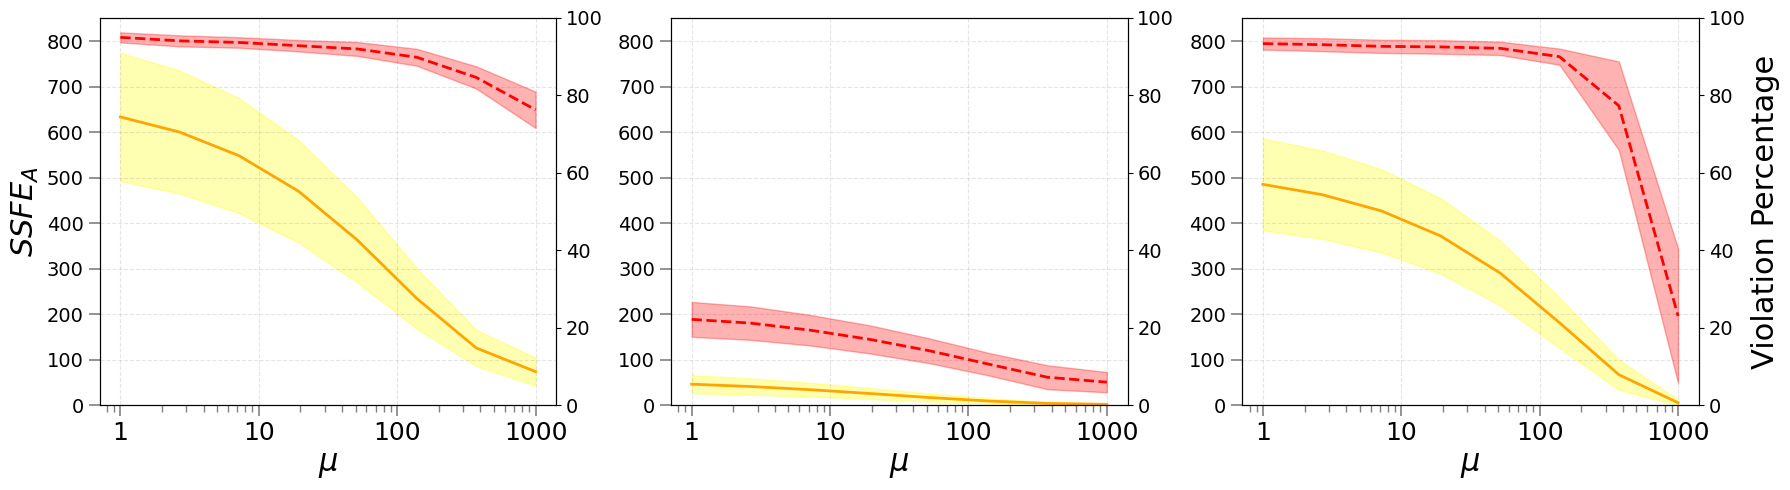

In [ ]:
y = df["logwage"].to_numpy()

feature_sets = [
    ("yeduc + exp", ["yeduc", "exp"]),
    ("yeduc + exp + exp2", ["yeduc", "exp", "exp2"]),
    ("yeduc + exp + age2017", ["yeduc", "exp", "age2017"])
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
highest_ssfe = 1
lowest_ssfe = 0
c = 100
s = 20
n = 100
x_steps = 8
confidence = 0.95
SSRE_range = np.logspace(np.log10(1), np.log10(1000), x_steps)

for plot_idx, (model_name, columns) in enumerate(tqdm(feature_sets, desc="models")):
  print(f"feature index {plot_idx} started at {str(datetime.now() + timedelta(hours=2))}")

  k = len(columns)
  Y = np.zeros((s, x_steps))
  V = np.zeros((s, x_steps))
  SSR_values = []

  for simu in tqdm(range(s), desc=f"{s} simulations", leave=False):
    df_sample = df.sample(n=n, replace=True)
    y_sample = df_sample["logwage"].to_numpy()
    X_sample = df_sample[columns].to_numpy()

    reg = LinearRegression(fit_intercept = True).fit(X_sample, y_sample)
    beta_0 = reg.intercept_
    beta_hat = reg.coef_.reshape(-1, 1)

    SSFE_range = np.zeros(x_steps)
    viol_range = np.zeros(x_steps)

    for idx, SSRE_A in enumerate(tqdm(SSRE_range, desc="SSRE iterations", leave=False)):
      solutions = optimize_A_rep(
        X=X_sample,
        y=y_sample,
        beta_hat=beta_hat,
        lam=SSRE_A,
        n_restarts=1,
        c = c
      )

      SSFE_A = SSFE(X=X_sample, f=f, A=solutions['A'], c=c)
      SSFE_range[idx] = SSFE_A
      viol_range[idx] = viol_percentage(y_sample, X_sample, A=solutions['A'], c=c)

    Y[simu, :] = SSFE_range
    V[simu, :] = viol_range

  df_ci = s - 1
  t_critical = t.ppf((1 + confidence) / 2, df_ci)

  mean_y = np.mean(Y, axis=0)
  stderr = sem(Y, axis=0)
  margin_ssfe = t_critical * stderr
  lower_ssfe = np.maximum(mean_y - margin_ssfe, 0)
  upper_ssfe = mean_y + margin_ssfe
  highest_ssfe = max(highest_ssfe, max(upper_ssfe))
  lowest_ssfe = min(lowest_ssfe, min(lower_ssfe))

  # Confidence interval for violations
  mean_v = np.mean(V, axis=0)
  stderr = sem(V, axis=0)
  margin_viol = t_critical * stderr
  lower_v = mean_v - margin_viol
  upper_v = mean_v + margin_viol

  # Plot
  ax1 = axes[plot_idx]

  ax1.plot(SSRE_range, mean_y, label='SSFE', linewidth=2, color="orange")
  ax1.fill_between(SSRE_range, lower_ssfe, upper_ssfe, alpha=0.3, color="yellow")
  ax1.set_xscale('log')
  #ax1.set_xscale('symlog', linthresh=1)
  ax1.set_xlabel(rf'$\mu$', fontsize=22)
  ax1.tick_params(axis='y', labelsize=14)
  ax1.tick_params(axis='both', which='major', length=8, width=1.2, color='gray')
  ax1.tick_params(axis='both', which='minor', length=5, width=1, color='gray')
  if plot_idx == 0:
    ax1.set_ylabel(r'$SSFE_A$', fontsize=22)

  ax2 = ax1.twinx()
  ax2.plot(SSRE_range, mean_v, linestyle='--', label='Violation %', color="red", linewidth=2)
  ax2.tick_params(axis='y', labelsize=14)
  ax2.fill_between(SSRE_range, lower_v, upper_v, alpha=0.3, color = "red")
  if plot_idx == 2:
    ax2.set_ylabel('Violation Percentage', fontsize=22)
  ax2.set_ylim(0, 100)

  ax1.grid(linestyle='--', color='gray', alpha=0.2)

  tick_positions = [1, 10, 100, 1000]
  tick_labels = [1, 10, 100, 1000]
  ax1.set_xticks(tick_positions)
  ax1.set_xticklabels(tick_labels, fontsize=18)

for ax in axes:
  ax.set_ylim(lowest_ssfe, 1.1*highest_ssfe)

print(f"done at {str(datetime.now() + timedelta(hours=2))}")
plt.tight_layout()
plt.show()

### scrap

models:   0%|          | 0/3 [00:00<?, ?it/s]

feature index 0 started at 2026-06-24 21:02:25.035972


20 simulations:   0%|          | 0/20 [00:00<?, ?it/s]

feature index 1 started at 2026-06-24 21:02:25.095553


20 simulations:   0%|          | 0/20 [00:00<?, ?it/s]

feature index 2 started at 2026-06-24 21:02:25.145358


20 simulations:   0%|          | 0/20 [00:00<?, ?it/s]

38.13
68.67828611022767


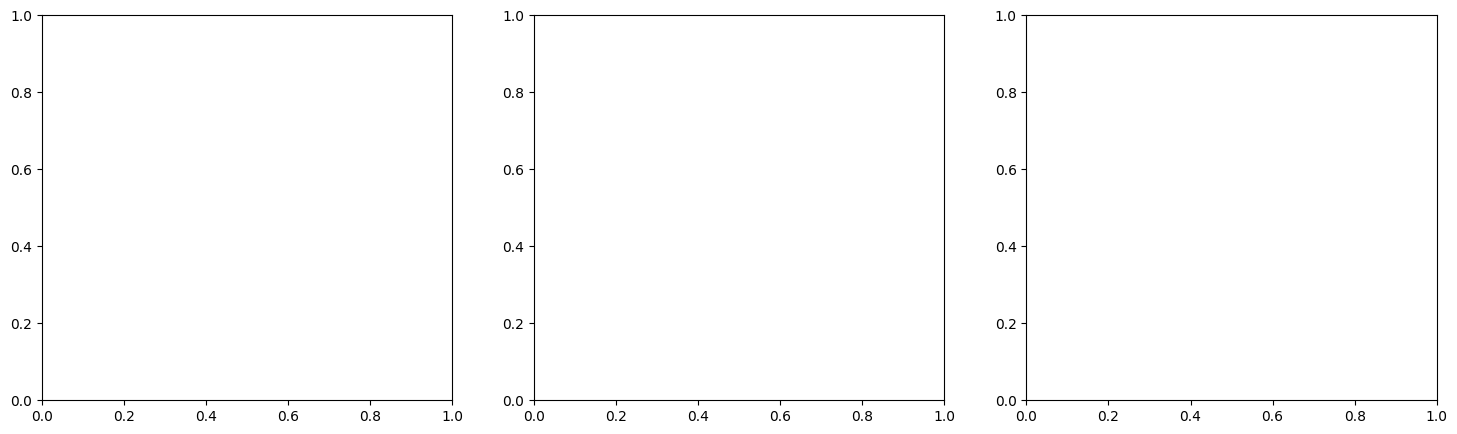

In [33]:
y = df["logwage"].to_numpy()

feature_sets = [
    ("yeduc + exp", ["yeduc", "exp"]),
    ("yeduc + exp + exp2", ["yeduc", "exp", "exp2"]),
    ("yeduc + exp + age2017", ["yeduc", "exp", "age2017"])
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
highest_ssfe = 1
lowest_ssfe = 0
c = 100
s = 20
n = 100
x_steps = 1
confidence = 0.95

for plot_idx, (model_name, columns) in enumerate(tqdm(feature_sets, desc="models")):
  print(f"feature index {plot_idx} started at {str(datetime.now() + timedelta(hours=2))}")

  k = len(columns)
  Y = np.zeros((s, x_steps))
  V = np.zeros((s, x_steps))
  SSR_values = []

  for simu in tqdm(range(s), desc=f"{s} simulations", leave=False):
    df_sample = df.sample(n=n, replace=True)
    y_sample = df_sample["logwage"].to_numpy()
    X_sample = df_sample[columns].to_numpy()

    reg = LinearRegression(fit_intercept = True).fit(X_sample, y_sample)
    beta_0 = reg.intercept_
    beta_hat = reg.coef_.reshape(-1, 1)

    SSR = np.sum((y_sample - beta_0 - X_sample @ beta_hat.flatten())**2)
    SSR_values.append(SSR)

mean_SSR = round(np.mean(SSR_values), 2)
var_SSR = np.var(SSR_values)

print(mean_SSR)
print(var_SSR)

models:   0%|          | 0/3 [00:00<?, ?it/s]

feature index 0 started at 2026-06-24 20:59:43.922515


20 simulations:   0%|          | 0/20 [00:00<?, ?it/s]

SSR iterations:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

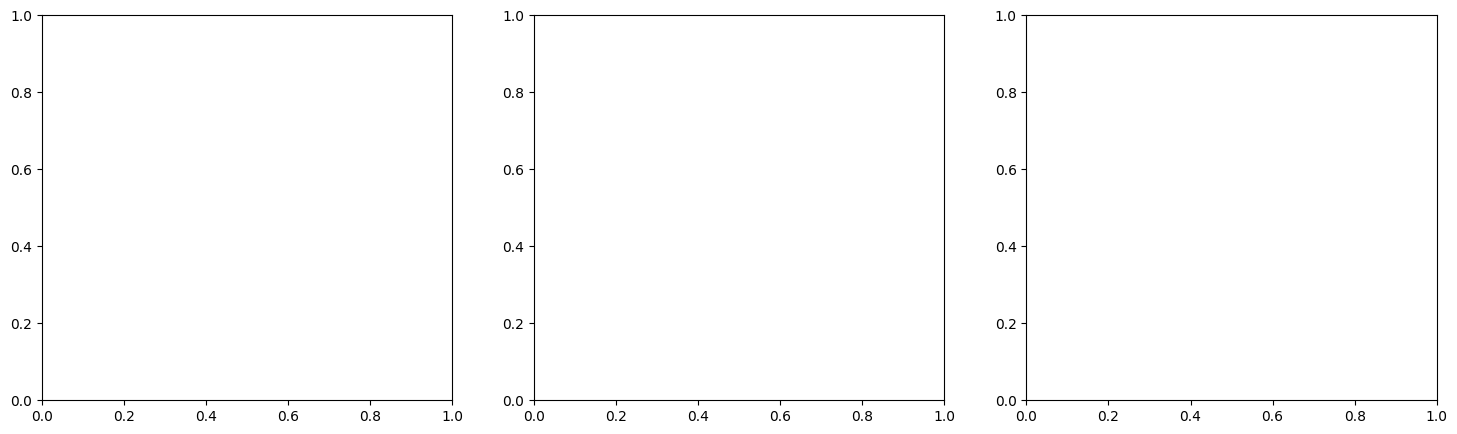

In [25]:
y = df["logwage"].to_numpy()

feature_sets = [
    ("yeduc + exp", ["yeduc", "exp"]),
    ("yeduc + exp + exp2", ["yeduc", "exp", "exp2"]),
    ("yeduc + exp + age2017", ["yeduc", "exp", "age2017"])
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
highest_ssfe = 1
lowest_ssfe = 0
c = 100
s = 20
n = 100
x_steps = 1
confidence = 0.95

for plot_idx, (model_name, columns) in enumerate(tqdm(feature_sets, desc="models")):
  print(f"feature index {plot_idx} started at {str(datetime.now() + timedelta(hours=2))}")

  k = len(columns)
  Y = np.zeros((s, x_steps))
  V = np.zeros((s, x_steps))
  SSR_values = []

  for simu in tqdm(range(s), desc=f"{s} simulations", leave=False):
    df_sample = df.sample(n=n, replace=True)
    y_sample = df_sample["logwage"].to_numpy()
    X_sample = df_sample[columns].to_numpy()

    reg = LinearRegression(fit_intercept = True).fit(X_sample, y_sample)
    beta_0 = reg.intercept_
    beta_hat = reg.coef_.reshape(-1, 1)

    SSR = np.sum((y_sample - beta_0 - X_sample @ beta_hat.flatten())**2)
    SSR_values.append(SSR)

    SSR_range = np.logspace(np.log10(SSR), np.log10(10*SSR), x_steps)

    SSFE_range = np.zeros(x_steps)
    viol_range = np.zeros(x_steps)

    for idx, SSR_A in enumerate(tqdm(SSR_range, desc="SSR iterations", leave=False)):
      solutions = optimize_A(
        X=X_sample,
        y=y_sample,
        beta_hat=beta_hat,
        lam=SSR_A,
        n_restarts=1,
        beta_0 = beta_0,
        c = c
      )

      SSFE_A = SSFE(X=X_sample, f=f, A=solutions['A'], c=c)
      SSFE_range[idx] = SSFE_A
      viol_range[idx] = viol_percentage(y_sample, X_sample, A=solutions['A'], c=c)
    Y[simu, :] = SSFE_range
    V[simu, :] = viol_range

  # Confidence interval for SSFE
  df_ci = s - 1
  t_critical = t.ppf((1 + confidence) / 2, df_ci)

  mean_y = np.mean(Y, axis=0)
  stderr = sem(Y, axis=0)
  margin_ssfe = t_critical * stderr
  lower_ssfe = np.maximum(mean_y - margin_ssfe, 0)
  upper_ssfe = mean_y + margin_ssfe
  highest_ssfe = max(highest_ssfe, max(upper_ssfe))
  lowest_ssfe = min(lowest_ssfe, min(lower_ssfe))

  # Confidence interval for violations
  mean_v = np.mean(V, axis=0)
  stderr = sem(V, axis=0)
  margin_viol = t_critical * stderr
  lower_v = mean_v - margin_viol
  upper_v = mean_v + margin_viol

  # Plot
  ax1 = axes[plot_idx]
  mean_SSR = round(np.mean(SSR_values), 2)
  var_SSR = np.var(SSR_values)

  ax1.plot(np.logspace(0, 1, x_steps), mean_y, label='SSFE', linewidth=2)
  ax1.fill_between(np.logspace(0, 1, x_steps), lower_ssfe, upper_ssfe, alpha=0.3)
  ax1.set_xscale('log')
  ax1.set_xlabel(rf'$\lambda \; (SSR \sim ({mean_SSR}, {var_SSR:.2e}))$', fontsize=22)
  ax1.tick_params(axis='y', labelsize=14)
  ax1.tick_params(axis='both', which='major', length=8, width=1.2, color='gray')
  ax1.tick_params(axis='both', which='minor', length=5, width=1, color='gray')
  if plot_idx == 0:
    ax1.set_ylabel(r'$SSFE_A$', fontsize=22)

  ax2 = ax1.twinx()
  ax2.plot(np.logspace(0, 1, x_steps), mean_v, linestyle='--', label='Violation %', color="red", linewidth=2)
  ax2.tick_params(axis='y', labelsize=14)
  ax2.fill_between(np.logspace(0, 1, x_steps), lower_v, upper_v, alpha=0.3, color = "red")
  if plot_idx == 2:
    ax2.set_ylabel('Violation Percentage', fontsize=22)
  ax2.set_ylim(0, 100)

  ax1.grid(linestyle='--', color='gray', alpha=0.2)

  tick_positions = [1, 10]
  tick_labels = [
      r'$SSR$',
      r'$10SSR$'
  ]
  ax1.set_xticks(tick_positions)
  ax1.set_xticklabels(tick_labels, fontsize=18)
for ax in axes:
    ax.set_ylim(lowest_ssfe, 1.1*highest_ssfe)

print(f"done at {str(datetime.now() + timedelta(hours=2))}")
plt.tight_layout()
plt.show()



models:   0%|          | 0/3 [00:00<?, ?it/s]

feature index 0 started at 2026-06-23 12:35:38.779201


1 simulations:   0%|          | 0/1 [00:00<?, ?it/s]

SSRE iterations:   0%|          | 0/2 [00:00<?, ?it/s]

feature index 1 started at 2026-06-23 12:35:41.818130


...

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:207: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


1 simulations:   0%|          | 0/1 [00:00<?, ?it/s]

SSRE iterations:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:207: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


done at 2026-06-23 12:35:50.147523


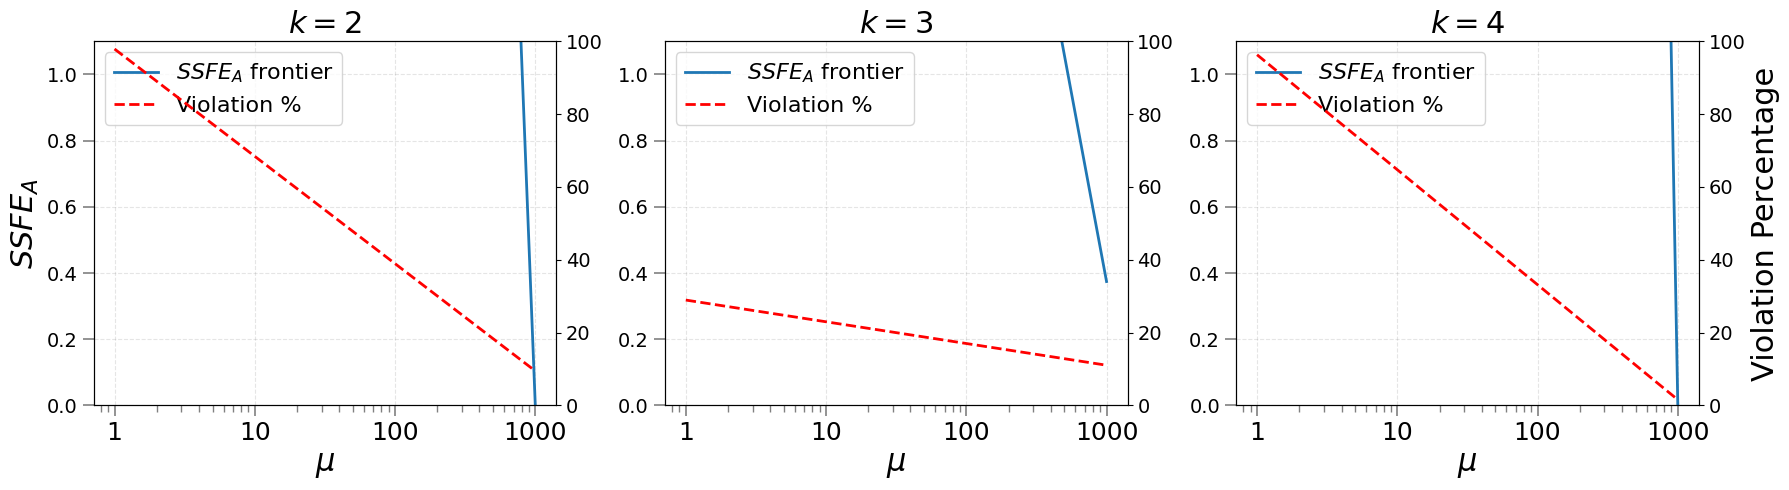

In [ ]:
y = df["logwage"].to_numpy()

feature_sets = [
    ("yeduc + exp", ["yeduc", "exp"]),
    ("yeduc + exp + exp2", ["yeduc", "exp", "exp2"]),
    ("yeduc + exp + age2017", ["yeduc", "exp", "age2017"])
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
highest_ssfe = 1
lowest_ssfe = 0
c = 60
s = 1
n = 20
x_steps = 2
confidence = 0.95
SSRE_range = np.logspace(np.log10(1), np.log10(1000), x_steps)

#model_significances = np.zeros([3, 4])

#A_properties = np.zeros([3, 3])

for plot_idx, (model_name, columns) in enumerate(tqdm(feature_sets, desc="models")):
  print(f"feature index {plot_idx} started at {str(datetime.now() + timedelta(hours=2))}")

  k = len(columns)
  Y = np.zeros((s, x_steps))
  V = np.zeros((s, x_steps))
  SSR_values = []

  for simu in tqdm(range(s), desc=f"{s} simulations", leave=False):
    df_sample = df.sample(n=n, replace=True)
    y_sample = df_sample["logwage"].to_numpy()
    X_sample = df_sample[columns].to_numpy()

    reg = LinearRegression(fit_intercept = True).fit(X_sample, y_sample)
    beta_0 = reg.intercept_
    beta_hat = reg.coef_.reshape(-1, 1)

    SSFE_range = np.zeros(x_steps)
    viol_range = np.zeros(x_steps)

    for idx, SSRE_A in enumerate(tqdm(SSRE_range, desc="SSRE iterations", leave=False)):
      solutions = optimize_A_rep(
        X=X_sample,
        y=y_sample,
        beta_hat=beta_hat,
        lam=SSRE_A,
        n_restarts=1,
        c = c
      )

      SSFE_A = SSFE(X=X_sample, f=f, A=solutions['A'], c=c)
      SSFE_range[idx] = SSFE_A
      viol_range[idx] = viol_percentage(y_sample, X_sample, A=solutions['A'], c=c) # Use y_sample and X_sample

    Y[simu, :] = SSFE_range
    V[simu, :] = viol_range

  # Confidence interval (for SSFE)
  df_ci = s - 1 # Renamed to avoid shadowing the DataFrame 'df'
  t_critical = t.ppf((1 + confidence) / 2, df_ci)

  mean_y = np.mean(Y, axis=0)
  stderr = sem(Y, axis=0)
  margin_ssfe = t_critical * stderr
  lower_ssfe = np.maximum(mean_y - margin_ssfe, 0)
  upper_ssfe = mean_y + margin_ssfe
  # Update global min/max SSFE for consistent y-axis limits across plots
  highest_ssfe = max(highest_ssfe, max(upper_ssfe))
  lowest_ssfe = min(lowest_ssfe, min(lower_ssfe)) # This handles zero if max(0, x) was applied

  # Confidence interval (for violations)
  mean_v = np.mean(V, axis=0)
  stderr = sem(V, axis=0)
  margin_viol = t_critical * stderr
  lower_v = mean_v - margin_viol
  upper_v = mean_v + margin_viol

  # Plot
  ax1 = axes[plot_idx]

  ax1.plot(SSRE_range, mean_y, linewidth=2, label='$SSFE_A$ frontier')
  ax1.fill_between(SSRE_range, lower_ssfe, upper_ssfe, alpha=0.3, color="yellow")
  ax1.set_xscale('log')
  ax1.set_title(f"$k = {plot_idx + 2}$", fontsize=22)
  #ax1.set_xscale('symlog', linthresh=1)
  ax1.set_xlabel(rf'$\mu$', fontsize=22)
  ax1.tick_params(axis='y', labelsize=14)
  ax1.tick_params(axis='both', which='major', length=8, width=1.2, color='gray')  # Major ticks
  ax1.tick_params(axis='both', which='minor', length=5, width=1, color='gray')   # Minor ticks (if any)
  if plot_idx == 0:
    ax1.set_ylabel(r'$SSFE_A$', fontsize=22)

  ax2 = ax1.twinx()
  ax2.plot(SSRE_range, mean_v, linestyle='--', color="red", linewidth=2, label='Violation %')
  ax2.tick_params(axis='y', labelsize=14)
  ax2.fill_between(SSRE_range, lower_v, upper_v, alpha=0.3, color = "red")
  if plot_idx == 2:
    ax2.set_ylabel('Violation Percentage', fontsize=22)
  ax2.set_ylim(0, 100)

  ax1.grid(linestyle='--', color='gray', alpha=0.2)

  tick_positions = [1, 10, 100, 1000]
  tick_labels = [1, 10, 100, 1000]
  ax1.set_xticks(tick_positions)
  ax1.set_xticklabels(tick_labels, fontsize=18)

  # Add legend for both axes to the current subplot
  lines1, labels1 = ax1.get_legend_handles_labels()
  lines2, labels2 = ax2.get_legend_handles_labels()
  ax1.legend(lines1 + lines2, labels1 + labels2, loc="best",fontsize=16)

for ax in axes:
  ax.set_ylim(lowest_ssfe, 1.1*highest_ssfe)

print(f"done at {str(datetime.now() + timedelta(hours=2))}")
plt.tight_layout()
plt.show()